# Fine-Tuning Improved RCAN for 10m → 2.5m Super Resolution

We start from our already trained Improved RCAN.

The goal is to improve spatial details such as buildings, roads and boundaries
while keeping the good pixel and spectral reconstruction of the existing model.

Baseline:

RMSE: 0.05548
PSNR: 25.118 dB
SSIM: 0.6905

In [2]:
!pip install -q tacoreader==0.6.5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 34.4 MB/s eta 0:00:0000:0100:01


In [3]:
import os
import random
import time
import gc

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from skimage.metrics import structural_similarity as ssim

import tacoreader.v1 as tacoreader
import rasterio

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


Now we load the same Sentinel-2 and NAIP dataset.
-
Sentinel-2 is our 10m input and NAIP is our 2.5m reference target.

In [4]:
dataset = tacoreader.load(
    "tacofoundation:sen2naipv2-unet"
)

def read_pair(index):
    sample = dataset.read(index)

    lr_path = sample.read(0)
    hr_path = sample.read(1)

    with rasterio.open(lr_path) as src:
        lr = src.read().astype(np.float32)

    with rasterio.open(hr_path) as src:
        hr = src.read().astype(np.float32)

    lr /= 3000.0
    hr /= 3000.0

    return lr, hr

We use the same normalization as the original RCAN training.
-
Both images contain 4 bands: RGB + NIR.

In [5]:
class RCAB(nn.Module):
    def __init__(self, channels=96, reduction=8):
        super().__init__()

        self.conv1 = nn.Conv2d(
            channels,
            channels,
            3,
            padding=1
        )

        self.relu = nn.ReLU(
            inplace=True
        )

        self.conv2 = nn.Conv2d(
            channels,
            channels,
            3,
            padding=1
        )

        self.avg_pool = nn.AdaptiveAvgPool2d(1)

        self.attention = nn.Sequential(
            nn.Conv2d(
                channels,
                channels // reduction,
                1
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                channels // reduction,
                channels,
                1
            ),
            nn.Sigmoid()
        )

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.relu(out)
        out = self.conv2(out)

        attention = self.avg_pool(out)
        attention = self.attention(attention)

        out = out * attention

        return residual + 0.1 * out


class ImprovedRCAN(nn.Module):
    def __init__(self):
        super().__init__()

        channels = 96

        self.head = nn.Conv2d(
            4,
            channels,
            3,
            padding=1
        )

        self.body = nn.Sequential(
            *[
                RCAB(channels)
                for _ in range(12)
            ]
        )

        self.body_conv = nn.Conv2d(
            channels,
            channels,
            3,
            padding=1
        )

        self.up1 = nn.Sequential(
            nn.Conv2d(
                channels,
                channels * 4,
                3,
                padding=1
            ),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        self.up2 = nn.Sequential(
            nn.Conv2d(
                channels,
                channels * 4,
                3,
                padding=1
            ),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        self.tail = nn.Conv2d(
            channels,
            4,
            3,
            padding=1
        )

    def forward(self, x):
        shallow = self.head(x)

        x = self.body(shallow)
        x = self.body_conv(x)
        x = x + shallow

        x = self.up1(x)
        x = self.up2(x)

        x = self.tail(x)

        return x

This is the exact architecture compatible with our saved Improved RCAN checkpoint.

We are not changing the model structure yet.

In [6]:
RCAN_PATH = (
    "/kaggle/input/models/"
    "nakulhemantkarpe/rcan-final/"
    "pytorch/default/1/"
    "rcan_improved.pth"
)

model = ImprovedRCAN().to(device)

checkpoint = torch.load(
    RCAN_PATH,
    map_location=device,
    weights_only=False
)

if "model_state_dict" in checkpoint:
    model.load_state_dict(
        checkpoint["model_state_dict"]
    )
else:
    model.load_state_dict(checkpoint)

model.eval()

print("Improved RCAN loaded successfully")
print(
    "Parameters:",
    sum(
        p.numel()
        for p in model.parameters()
    )
)

Improved RCAN loaded successfully
Parameters: 2776276


The pretrained RCAN is now loaded.
-
Next we will build the fine-tuning dataset and use a loss that puts more importance on spatial structure while still protecting RGB + NIR reconstruction.

### Fine-tuning strategy

We are not training RCAN from scratch.

We start from the existing Improved RCAN weights and fine-tune them with a lower learning rate.

The new loss gives more importance to:

- Pixel accuracy
- Building and road edges
- Fine spatial details
- RGB + NIR spectral consistency

The original RCAN remains our baseline, so we can compare both models after fine-tuning.

In [8]:
class FineTuneDataset(Dataset):
    def __init__(
        self,
        indices,
        patch_size=32,
        patches_per_epoch=400
    ):
        self.indices = indices
        self.patch_size = patch_size
        self.patches_per_epoch = patches_per_epoch

    def __len__(self):
        return self.patches_per_epoch

    def __getitem__(self, idx):

        image_index = random.choice(
            self.indices
        )

        lr, hr = read_pair(
            image_index
        )

        ps = self.patch_size

        max_y = lr.shape[1] - ps
        max_x = lr.shape[2] - ps

        y = random.randint(
            0,
            max_y
        )

        x = random.randint(
            0,
            max_x
        )

        lr_patch = lr[
            :,
            y:y + ps,
            x:x + ps
        ]

        hr_patch = hr[
            :,
            y * 4:y * 4 + ps * 4,
            x * 4:x * 4 + ps * 4
        ]

        return (
            torch.from_numpy(
                lr_patch
            ).float(),

            torch.from_numpy(
                hr_patch
            ).float()
        )

Here we take small 10m patches and their matching NAIP patches.
-
A 32×32 Sentinel-2 patch corresponds to a 128×128 NAIP patch because our target scale is ×4.

In [9]:
TRAIN_INDICES = list(
    range(200)
)

VAL_INDICES = list(
    range(200, 220)
)

PATCH_SIZE = 32
PATCHES_PER_EPOCH = 400
BATCH_SIZE = 8

train_dataset = FineTuneDataset(
    indices=TRAIN_INDICES,
    patch_size=PATCH_SIZE,
    patches_per_epoch=PATCHES_PER_EPOCH
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

print(
    "Training patches:",
    len(train_dataset)
)

print(
    "Training batches:",
    len(train_loader)
)

Training patches: 400
Training batches: 50


In [10]:
TRAIN_INDICES = list(
    range(200)
)

VAL_INDICES = list(
    range(200, 220)
)

PATCH_SIZE = 32
PATCHES_PER_EPOCH = 400
BATCH_SIZE = 8

train_dataset = FineTuneDataset(
    indices=TRAIN_INDICES,
    patch_size=PATCH_SIZE,
    patches_per_epoch=PATCHES_PER_EPOCH
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

print(
    "Training patches:",
    len(train_dataset)
)

print(
    "Training batches:",
    len(train_loader)
)

Training patches: 400
Training batches: 50


We use the same training images as before and keep images 200–219 for validation.
-
This lets us compare the fine-tuned model fairly against our existing baseline.

In [11]:
class CharbonnierLoss(nn.Module):
    def __init__(self, epsilon=1e-3):
        super().__init__()
        self.epsilon = epsilon

    def forward(self, pred, target):
        diff = pred - target

        return torch.mean(
            torch.sqrt(
                diff * diff +
                self.epsilon ** 2
            )
        )


def gradient_loss(pred, target):

    pred_x = (
        pred[:, :, :, 1:] -
        pred[:, :, :, :-1]
    )

    pred_y = (
        pred[:, :, 1:, :] -
        pred[:, :, :-1, :]
    )

    target_x = (
        target[:, :, :, 1:] -
        target[:, :, :, :-1]
    )

    target_y = (
        target[:, :, 1:, :] -
        target[:, :, :-1, :]
    )

    return (
        F.l1_loss(pred_x, target_x) +
        F.l1_loss(pred_y, target_y)
    )


def laplacian_loss(pred, target):

    kernel = torch.tensor(
        [
            [0., 1., 0.],
            [1., -4., 1.],
            [0., 1., 0.]
        ],
        device=pred.device
    )

    kernel = kernel.view(
        1, 1, 3, 3
    )

    kernel = kernel.repeat(
        pred.shape[1],
        1,
        1,
        1
    )

    pred_lap = F.conv2d(
        pred,
        kernel,
        padding=1,
        groups=pred.shape[1]
    )

    target_lap = F.conv2d(
        target,
        kernel,
        padding=1,
        groups=target.shape[1]
    )

    return F.l1_loss(
        pred_lap,
        target_lap
    )


def spectral_angle_loss(
    pred,
    target,
    eps=1e-6
):

    pred_flat = pred.permute(
        0, 2, 3, 1
    ).reshape(-1, 4)

    target_flat = target.permute(
        0, 2, 3, 1
    ).reshape(-1, 4)

    pred_norm = F.normalize(
        pred_flat,
        p=2,
        dim=1,
        eps=eps
    )

    target_norm = F.normalize(
        target_flat,
        p=2,
        dim=1,
        eps=eps
    )

    cosine = torch.sum(
        pred_norm * target_norm,
        dim=1
    )

    cosine = torch.clamp(
        cosine,
        min=-1.0 + 1e-4,
        max=1.0 - 1e-4
    )

    return torch.mean(
        1.0 - cosine
    )

This loss setup is the main change.
--
Laplacian and gradient losses make the network care more about high-frequency structures like building and road boundaries.

Spectral angle keeps the four Sentinel-2 bands consistent.

In [14]:
class RCANFineTuneLoss(nn.Module):
    def __init__(self):
        super().__init__()

        self.charbonnier = CharbonnierLoss()

        self.w_charb = 1.0
        self.w_mse = 0.50
        self.w_edge = 0.15
        self.w_laplacian = 0.10
        self.w_sam = 0.08

    def forward(self, pred, target):

        charb = self.charbonnier(
            pred,
            target
        )

        mse = F.mse_loss(
            pred,
            target
        )

        edge = gradient_loss(
            pred,
            target
        )

        laplacian = laplacian_loss(
            pred,
            target
        )

        sam = spectral_angle_loss(
            pred,
            target
        )

        total = (
            self.w_charb * charb +
            self.w_mse * mse +
            self.w_edge * edge +
            self.w_laplacian * laplacian +
            self.w_sam * sam
        )

        losses = {
            "charb": charb,
            "mse": mse,
            "edge": edge,
            "laplacian": laplacian,
            "sam": sam,
            "total": total
        }

        return total, losses

Now the fine-tuning loss is ready.
-
We intentionally keep the edge weights moderate. We want sharper learned reconstruction, not artificial-looking edges or hallucinated buildings.

Next we set the fine-tuning learning rate and optimizer.

In [15]:
criterion = RCANFineTuneLoss().to(
    device
)

LEARNING_RATE = 1e-5
WEIGHT_DECAY = 1e-4
EPOCHS = 10

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)

BEST_PATH = (
    "/kaggle/working/"
    "rcan_finetuned_best.pth"
)

FINAL_PATH = (
    "/kaggle/working/"
    "rcan_finetuned_final.pth"
)

print("Fine-tuning setup ready")
print("Learning rate:", LEARNING_RATE)
print("Epochs:", EPOCHS)

Fine-tuning setup ready
Learning rate: 1e-05
Epochs: 10


### Fine-tuning sanity check

Before starting the full run, we test one batch.

This makes sure the model, dataset and new detail-focused loss are all working correctly.

In [16]:
batch_lr, batch_hr = next(
    iter(train_loader)
)

batch_lr = batch_lr.to(
    device,
    non_blocking=True
)

batch_hr = batch_hr.to(
    device,
    non_blocking=True
)

model.train()

with torch.no_grad():
    batch_pred = model(batch_lr)

batch_loss, batch_losses = criterion(
    batch_pred,
    batch_hr
)

print("Input :", batch_lr.shape)
print("Target:", batch_hr.shape)
print("Output:", batch_pred.shape)
print("Loss  :", batch_loss.item())

Input : torch.Size([8, 4, 32, 32])
Target: torch.Size([8, 4, 128, 128])
Output: torch.Size([8, 4, 128, 128])
Loss  : 0.07071763277053833


In [18]:
from tqdm.auto import tqdm

model.train()

best_val_rmse = float("inf")
history = []

for epoch in range(EPOCHS):
    start_time = time.time()
    model.train()
    running_loss = 0.0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}",
        leave=True
    )

    for lr_batch, hr_batch in progress:
        lr_batch = lr_batch.to(device, non_blocking=True)
        hr_batch = hr_batch.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        prediction = model(lr_batch)
        loss, losses = criterion(prediction, hr_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_loss += loss.item()

        progress.set_postfix(
            loss=f"{loss.item():.5f}",
            lr=f"{optimizer.param_groups[0]['lr']:.2e}"
        )

    scheduler.step()

    train_loss = running_loss / len(train_loader)

    model.eval()

    val_squared_error = 0.0
    val_count = 0
    val_ssim_scores = []

    with torch.no_grad():
        for image_index in VAL_INDICES:
            lr, hr = read_pair(image_index)

            lr_tensor = (
                torch.from_numpy(lr)
                .unsqueeze(0)
                .float()
                .to(device)
            )

            prediction = model(lr_tensor)

            prediction_np = prediction.squeeze(0).cpu().numpy()
            target_np = hr

            mse = np.mean((prediction_np - target_np) ** 2)

            val_squared_error += mse * target_np.size
            val_count += target_np.size

            ssim_value = ssim(
                target_np.transpose(1, 2, 0),
                prediction_np.transpose(1, 2, 0),
                channel_axis=2,
                data_range=1
            )

            val_ssim_scores.append(ssim_value)

    val_mse = val_squared_error / val_count
    val_rmse = np.sqrt(val_mse)
    val_psnr = 10 * np.log10(1.0 / (val_mse + 1e-10))
    val_ssim = np.mean(val_ssim_scores)

    elapsed = time.time() - start_time

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "rmse": val_rmse,
        "psnr": val_psnr,
        "ssim": val_ssim
    })

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss {train_loss:.6f} | "
        f"RMSE {val_rmse:.6f} | "
        f"PSNR {val_psnr:.4f} dB | "
        f"SSIM {val_ssim:.6f} | "
        f"Time {elapsed:.1f}s"
    )

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse

        torch.save({
            "model_state_dict": model.state_dict(),
            "epoch": epoch + 1,
            "rmse": val_rmse,
            "psnr": val_psnr,
            "ssim": val_ssim
        }, BEST_PATH)

        print("✓ Best model saved")

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Epoch 1/10:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/10 | Loss 0.066589 | RMSE 0.069393 | PSNR 23.1736 dB | SSIM 0.676552 | Time 818.9s
✓ Best model saved


Epoch 2/10:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 2/10 | Loss 0.070189 | RMSE 0.069408 | PSNR 23.1719 dB | SSIM 0.676984 | Time 812.3s


Epoch 3/10:   0%|          | 0/50 [00:00<?, ?it/s]

...

Epoch 8/10 | Loss 0.065704 | RMSE 0.069258 | PSNR 23.1906 dB | SSIM 0.677949 | Time 220.8s


Epoch 9/10:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 9/10 | Loss 0.064546 | RMSE 0.069259 | PSNR 23.1904 dB | SSIM 0.677896 | Time 223.4s


Epoch 10/10:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 10/10 | Loss 0.065558 | RMSE 0.069225 | PSNR 23.1947 dB | SSIM 0.678024 | Time 217.8s
✓ Best model saved


In [19]:
torch.save({
    "model_state_dict": model.state_dict(),
    "epoch": EPOCHS,
    "best_val_rmse": best_val_rmse,
    "history": history
}, FINAL_PATH)

print("Final model saved:", FINAL_PATH)
print("Best validation RMSE:", best_val_rmse)

Final model saved: /kaggle/working/rcan_finetuned_final.pth
Best validation RMSE: 0.06922522


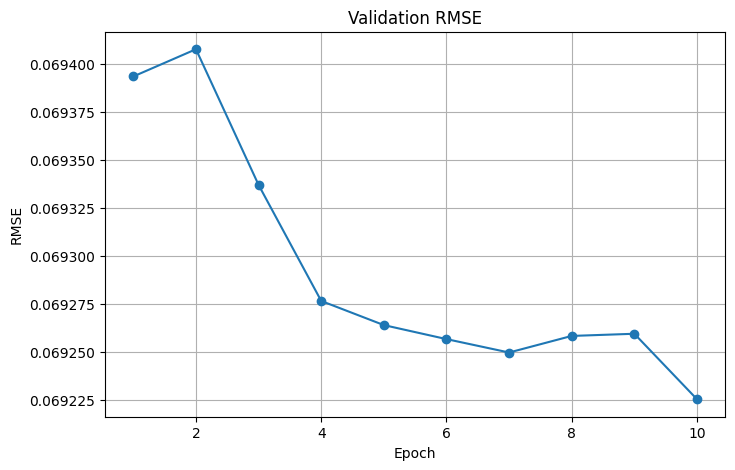

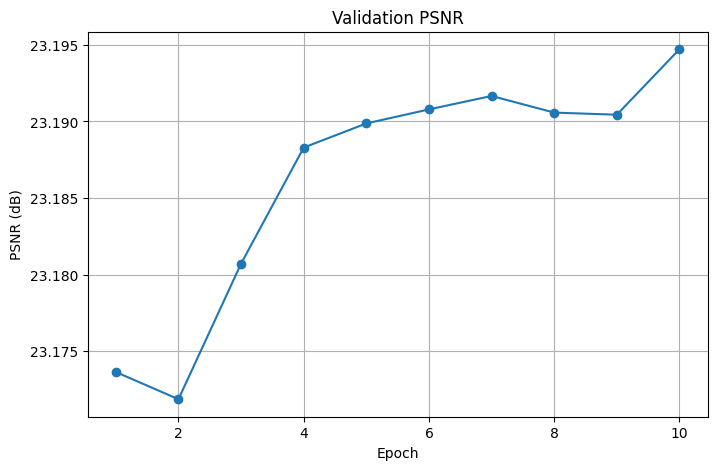

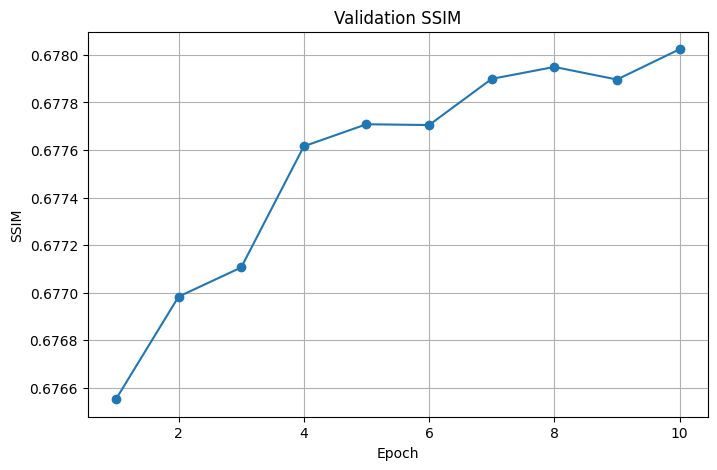

,epoch,train_loss,rmse,psnr,ssim
0,1,0.066589,0.069393,23.173639,0.676552
1,2,0.070189,0.069408,23.171864,0.676984
2,3,0.065421,0.069337,23.180716,0.677106
3,4,0.065731,0.069276,23.188293,0.677616
4,5,0.065560,0.069264,23.189869,0.677708
5,6,0.064777,0.069257,23.190784,0.677705
6,7,0.063954,0.069250,23.191662,0.677899
7,8,0.065704,0.069258,23.190577,0.677949
8,9,0.064546,0.069259,23.190437,0.677896
9,10,0.065558,0.069225,23.194714,0.678024


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_df["epoch"], history_df["rmse"], marker="o")
ax.set_xlabel("Epoch")
ax.set_ylabel("RMSE")
ax.set_title("Validation RMSE")
ax.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_df["epoch"], history_df["psnr"], marker="o")
ax.set_xlabel("Epoch")
ax.set_ylabel("PSNR (dB)")
ax.set_title("Validation PSNR")
ax.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_df["epoch"], history_df["ssim"], marker="o")
ax.set_xlabel("Epoch")
ax.set_ylabel("SSIM")
ax.set_title("Validation SSIM")
ax.grid(True)
plt.show()

history_df

In [21]:
checkpoint = torch.load(
    BEST_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

predictions = []
targets = []

with torch.no_grad():
    for image_index in VAL_INDICES:
        lr, hr = read_pair(image_index)

        lr_tensor = (
            torch.from_numpy(lr)
            .unsqueeze(0)
            .float()
            .to(device)
        )

        pred = model(lr_tensor)

        predictions.append(pred.squeeze(0).cpu().numpy())
        targets.append(hr)

predictions = np.stack(predictions)
targets = np.stack(targets)

mse = np.mean((predictions - targets) ** 2)
rmse = np.sqrt(mse)
psnr = 10 * np.log10(1.0 / (mse + 1e-10))

ssim_scores = []

for i in range(len(targets)):
    score = ssim(
        targets[i].transpose(1, 2, 0),
        predictions[i].transpose(1, 2, 0),
        channel_axis=2,
        data_range=1
    )
    ssim_scores.append(score)

mean_ssim = np.mean(ssim_scores)

print(f"Fine-tuned RCAN RMSE : {rmse:.6f}")
print(f"Fine-tuned RCAN PSNR : {psnr:.4f} dB")
print(f"Fine-tuned RCAN SSIM : {mean_ssim:.6f}")

Fine-tuned RCAN RMSE : 0.069225
Fine-tuned RCAN PSNR : 23.1947 dB
Fine-tuned RCAN SSIM : 0.678024


In [22]:
comparison = pd.DataFrame({
    "Model": [
        "Improved RCAN",
        "Residual HAT + RCAN",
        "Fine-tuned RCAN"
    ],
    "RMSE": [
        0.05548,
        0.074747,
        rmse
    ],
    "PSNR (dB)": [
        25.118,
        22.5282,
        psnr
    ],
    "SSIM": [
        0.6905,
        0.657414,
        mean_ssim
    ]
})

comparison

,Model,RMSE,PSNR (dB),SSIM
0,Improved RCAN,0.055480,25.118000,0.690500
1,Residual HAT + RCAN,0.074747,22.528200,0.657414
2,Fine-tuned RCAN,0.069225,23.194714,0.678024


In [23]:
URBAN_INDICES = [216, 217, 218, 219]

urban_results = {}

model.eval()

with torch.no_grad():
    for image_index in URBAN_INDICES:
        lr, hr = read_pair(image_index)

        lr_tensor = (
            torch.from_numpy(lr)
            .unsqueeze(0)
            .float()
            .to(device)
        )

        prediction = model(lr_tensor)

        urban_results[image_index] = {
            "lr": lr,
            "hr": hr,
            "prediction": prediction.squeeze(0).cpu().numpy()
        }

print("Generated predictions for:", URBAN_INDICES)

Generated predictions for: [216, 217, 218, 219]


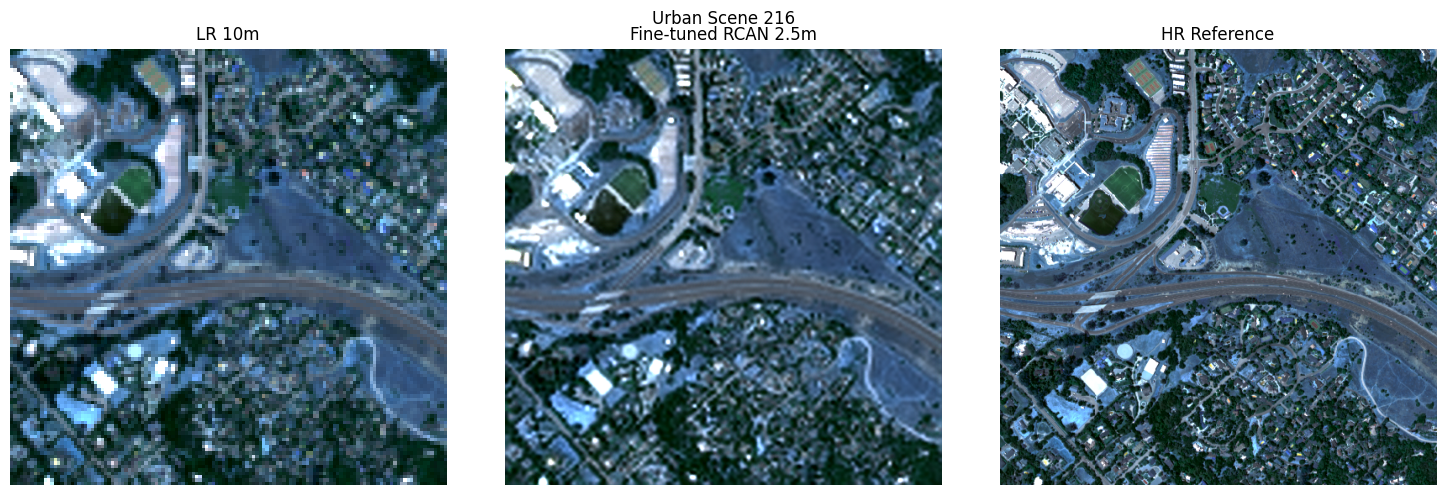

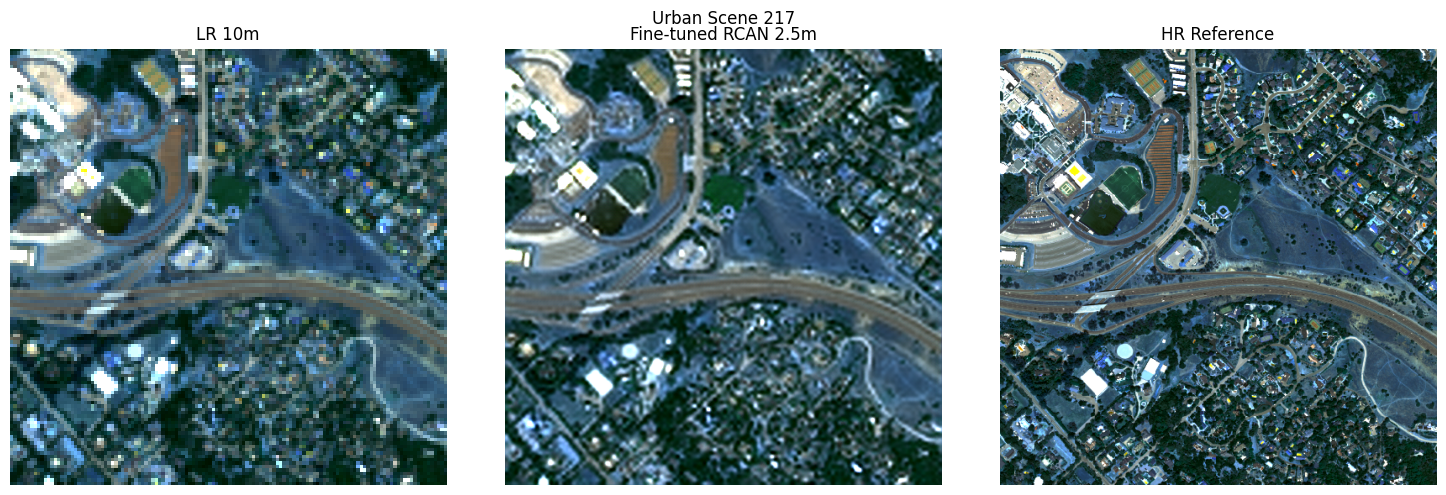

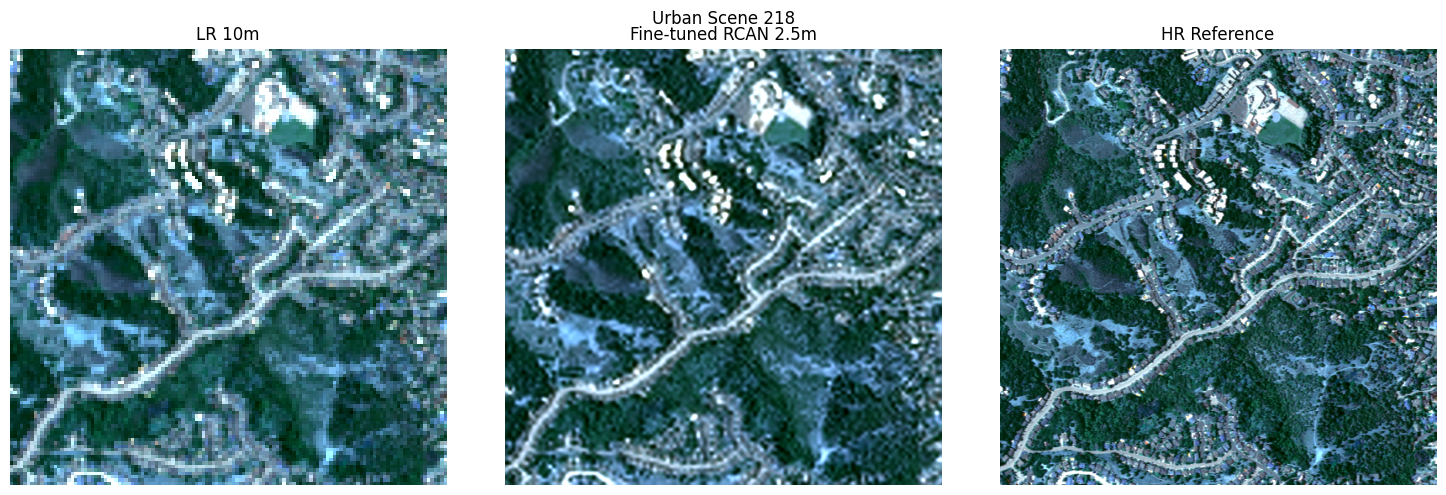

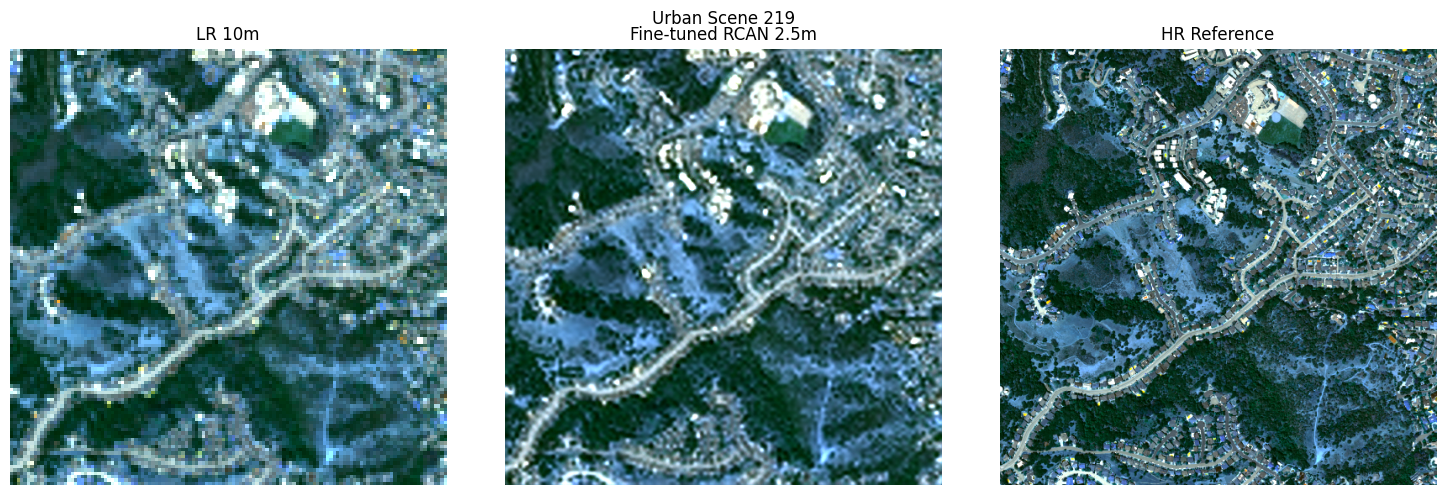

In [24]:
def make_rgb(image):
    rgb = image[[2, 1, 0]]
    rgb = np.transpose(rgb, (1, 2, 0))
    rgb = np.clip(rgb, 0, 1)

    low = np.percentile(rgb, 2)
    high = np.percentile(rgb, 98)

    rgb = (rgb - low) / (high - low + 1e-8)
    return np.clip(rgb, 0, 1)


for image_index in URBAN_INDICES:
    result = urban_results[image_index]

    lr_rgb = make_rgb(result["lr"])
    hr_rgb = make_rgb(result["hr"])
    pred_rgb = make_rgb(result["prediction"])

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(lr_rgb)
    axes[0].set_title("LR 10m")

    axes[1].imshow(pred_rgb)
    axes[1].set_title("Fine-tuned RCAN 2.5m")

    axes[2].imshow(hr_rgb)
    axes[2].set_title("HR Reference")

    for ax in axes:
        ax.axis("off")

    plt.suptitle(f"Urban Scene {image_index}")
    plt.tight_layout()
    plt.show()

In [ ]:
final_checkpoint = torch.load(
    BEST_PATH,
    map_location="cpu",
    weights_only=False
)

final_checkpoint["architecture"] = {
    "model": "Improved RCAN",
    "blocks": 12,
    "channels": 96,
    "scale": 4,
    "bands": 4
}

final_checkpoint["normalization"] = {
    "divisor": 3000.0
}

final_checkpoint["training"] = {
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "epochs": EPOCHS,
    "patch_size": 32
}

torch.save(final_checkpoint, "/kaggle/working/rcan_mvp_best.pth")

print("MVP checkpoint saved:")
print("/kaggle/working/rcan_mvp_best.pth")